# Элементарная свёртка с ядром для горизонтальных и вертикальных линий

In [1]:
from PIL import Image
from matplotlib import pyplot as plt
import torch
from torchvision.transforms.functional import to_tensor
import numpy as np

In [4]:
image = Image.open("./data/img.png")
image_tensor = to_tensor(image) # тензор [1, 28, 28]

# добавлено ещё одно измерение, чтобы получить [1, 1, 28, 28]
image_tensor = image_tensor.unsqueeze(0) 

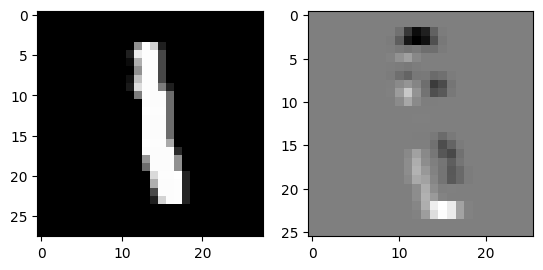

In [5]:
kernel_horizontal = torch.Tensor([[[[3, 10, 3], 
                         [0, 0, 0], 
                         [-3, -10, -3]]]])

result = torch.nn.functional.conv2d(image_tensor, kernel_horizontal)

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray')

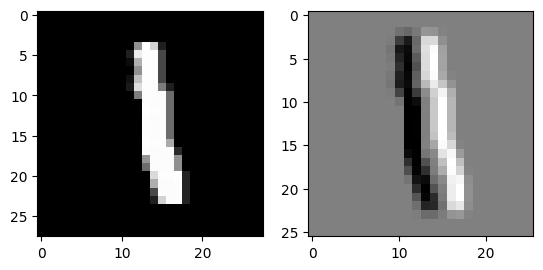

In [6]:
kernel_vertical = torch.Tensor([[[[3, 0, -3], 
                        [10, 0, -10], 
                        [3, 0, -3]]]])
                        
result = torch.nn.functional.conv2d(image_tensor, kernel_vertical)

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray')

## Цветной вариант (3х-канальный)

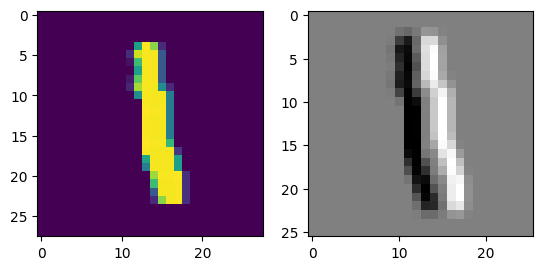

In [13]:
image_col = Image.open("./data/img_colored.png")
image_col_tensor = to_tensor(image_col) # тензор [1, 3, 28, 28]
image_col_tensor = image_col_tensor.unsqueeze(0) 

kernel = np.array([[3, 0, -3], # обычный фильтр вертикальных линий
                   [10, 0, -10],
                   [3, 0, -3]])

kernel_3D = torch.Tensor(np.tile(kernel, (3, 1, 1)))
kernel_3D = kernel_3D.unsqueeze(0) # приведён к форме [1, 3, 3, 3]

result = torch.nn.functional.conv2d(image_col_tensor, kernel_3D)

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray')

Или так:

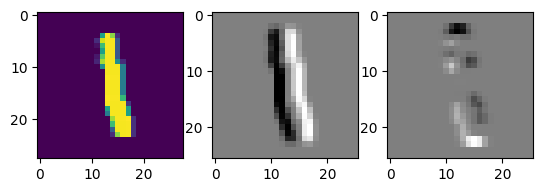

In [14]:
kernel_v = np.array([[3, 0, -3], # обычный фильтр вертикальных линий
                     [10, 0, -10],
                     [3, 0, -3]])

kernel_h = np.array([[3, 10, 3], # обычный фильтр горизонтальных линий
                     [0, 0, 0],
                     [-3, -10, -3]])

kernel_v_3D = np.tile(kernel_v, (3, 1, 1)) # трёхмерный фильтр вертикальных линий

kernel_h_3D = np.tile(kernel_h, (3, 1, 1)) # трёхмерный фильтр горизонтальных линий

kernels = torch.Tensor(np.stack([kernel_v_3D, kernel_h_3D])) # тензор с фильтрами

result = torch.nn.functional.conv2d(image_col_tensor, kernels)

# визуализация
fig = plt.figure()
plt.subplot(1, 3, 1)
plt.imshow(image)

plt.subplot(1, 3, 2)
plt.imshow(result[0][0], cmap='gray') # карта признака вертикальных линий

plt.subplot(1, 3, 3)
plt.imshow(result[0][1], cmap='gray') # карта признака горизонтальных линий 

# Conv2D()

In [2]:
import torch.nn as nn

In [21]:
conv_layer = nn.Conv2d(3, 20, 3)
result = conv_layer(image_col_tensor).detach()

print("Размерность тензора: ", result.shape) 

Размерность тензора:  torch.Size([1, 20, 26, 26])


# Pooling

In [3]:
image_car = Image.open("./data/car.png")
image_car_tensor = to_tensor(image_car)
image_car_tensor = image_car_tensor.unsqueeze(0)

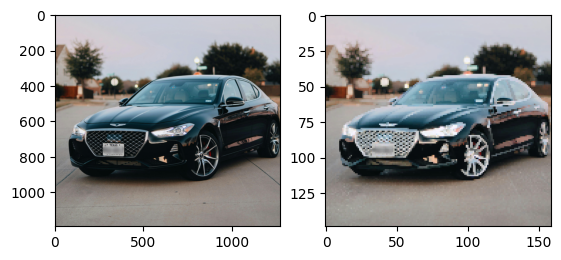

In [5]:
pool_layer = nn.MaxPool2d(8)
result = pool_layer(image_car_tensor).detach()

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image_car)

plt.subplot(1, 2, 2)
plt.imshow(result[0].permute(1, 2, 0))

# AlexNet

![Архитектура](./docs/alexnet.png)

In [5]:
model = nn.Sequential(
    nn.Conv2d(3, 96, kernel_size=11, stride=4),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    
    nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
        
    nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    
    nn.Flatten(),
    nn.Dropout(),
    nn.Linear(9216, 4096),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    
    nn.Linear(4096, 1000),
    nn.Softmax(dim=1)
)

print("Архитектура модели:", model)
print("Количество параметров:", sum(p.numel() for p in model.parameters()))

Архитектура модели: Sequential(
  (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU()
  (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU()
  (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Flatten(start_dim=1, end_dim=-1)
  (14): Dropout(p=0.5, inplace=False)
  (15): Linear(in_features=9216, out_features=4096, bias=True)
  (16): ReLU()
  (17): Dropout(p=0.5, inplace=False)
  (18): Linear(in_features=4096, out_features=4096, bias=True)
  (19): ReLU()
  (20): Linear(in_f

# ResNet

## Residual-блок

![Архитектура](./docs/resnet.png)

In [3]:
import torch.nn as nn
from torch import Tensor

In [6]:
class ResidualBlock(nn.Module):
    def __init__(
        self,
        inputs: int,
        hidden: int,
        outputs: int,
        stride: int = 1,
    ) -> None:
        super().__init__()

        self.conv1 = nn.Conv2d(inputs,
                               hidden,
                               kernel_size=3,
                               stride=stride,
                               bias=False,
                               padding='same')
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(hidden,
                               hidden,
                               kernel_size=3,
                               stride=stride,
                               bias=False,
                               padding='same')
        self.conv3 = nn.Conv2d(hidden,
                               outputs,
                               kernel_size=3,
                               stride=stride,
                               bias=False,
                               padding='same')

    def forward(self, x: Tensor) -> Tensor:
        identity = x
        
        x1 = self.conv1(x)
        x1_out = self.relu(x1)
        
        x2 = self.conv2(x1_out)
        x2_out = self.rule(x2)
        
        x3 = self.conv3(x2_out)
        out = x3_out + identity
        out = self.relu(out)

        return out

In [7]:
print("Архитектура модели:", ResidualBlock(256, 64, 256))

Архитектура модели: ResidualBlock(
  (conv1): Conv2d(256, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
  (relu): ReLU()
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
  (conv3): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
)


## BottleNeck-блок

In [10]:
model = nn.Sequential(
    nn.Conv2d(512, 48, 1, padding='same'), # сжатие тензора, была размерность w*h*512, стала w*h*48
    nn.Conv2d(48, 48, 3, padding='same'),
    # восстановление тензора, была размерность w*h*48, стала w*h*512
    nn.Conv2d(48, 512, 1, padding='same'), 
)
print('Количество параметров:', sum(p.numel() for p in model.parameters()))

Количество параметров: 70496


![Архитектура](./docs/bottleneck.png)

In [12]:
class BottleneckBlock(nn.Module):

    def __init__(
        self,
        inputs: int,
        hidden: int,
        outputs: int,
        stride: int = 1,
    ) -> None:
        super().__init__()
        self.relu = nn.ReLU()
        norm_layer = nn.BatchNorm2d
        self.conv1 = nn.Conv2d(inputs, 
                               hidden,
                               kernel_size=1,
                               stride=stride,
                               bias=False,
                               padding="same")
        self.bn1 = norm_layer(hidden)
        
        self.conv2 = nn.Conv2d(hidden, 
                               hidden,
                               kernel_size=3,
                               stride=stride,
                               bias=False,
                               padding="same")
        self.bn2 = norm_layer(hidden)
        
        self.conv3 = nn.Conv2d(hidden, 
                               outputs,
                               kernel_size=1,
                               stride=stride,
                               bias=False,
                               padding="same")
        self.bn3 = norm_layer(outputs)

    def forward(self, x: Tensor) -> Tensor:
        x1 = self.conv1(x)
        norm1 = self.bn1(x1)
        out1 = self.relu(norm1)
        
        x2 = self.conv2(out1)
        norm2 = self.bn1(x2)
        out2 = self.relu(norm2)
        
        x3 = self.conv3(out2)
        norm3 = self.bn3(x3)
        out3 = self.relu(norm3)
        
        out = x + out3
        
        return out

In [13]:
model = BottleneckBlock(256, 64, 256)
print("Архитектура блока:", model)
print("Количество параметров:", sum(p.numel() for p in model.parameters()))

Архитектура блока: BottleneckBlock(
  (relu): ReLU()
  (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), padding=same, bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), padding=same, bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
Количество параметров: 70400


In [14]:
from torchsummary import summary # метод для распечатки архитектуры

In [21]:
class Classificator(nn.Module):

    def __init__(
        self,
        n_classes: int,
    ) -> None:
        super().__init__()
        norm_layer = nn.BatchNorm2d
        
        # входная свёртка + батчнорм + релу
        self.conv = nn.Conv2d(3,
                              64,
                              kernel_size=7,
                              bias=False,
                              stride=2,
                              padding=3)
        self.bn = norm_layer(64)
        self.relu = nn.ReLU()
        
        # слой макс-пулинга
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        
        # слои для residual bottleneck блока
        self.resblock = BottleneckBlock(64, 16, 64)
        
        # слой глобального пулинга
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        # Полносвязная часть в конце
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64, n_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x: Tensor) -> Tensor:
        # входная свёртка + батчнорм + релу
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        
        # макс-пулинг
        out = self.maxpool(out)

        # residual bottleneck блок
        out = self.resblock(out)
                
        # глобальный пулинг
        out = self.avgpool(out)        
                
        # полносвязная часть для классификации
        out = self.flatten(out)
        out = self.fc(out)
        out = self.softmax(out)

        return out

In [22]:
model = Classificator(10)
print("Количество параметров:", sum(p.numel() for p in model.parameters()))

# визуализация архитектуры при распознавании изображений размером 224х224х3
summary(model, input_size=(3, 224, 224),  device = 'cpu') 

Количество параметров: 14730
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 16, 56, 56]           1,024
       BatchNorm2d-6           [-1, 16, 56, 56]              32
              ReLU-7           [-1, 16, 56, 56]               0
            Conv2d-8           [-1, 16, 56, 56]           2,304
       BatchNorm2d-9           [-1, 16, 56, 56]              32
             ReLU-10           [-1, 16, 56, 56]               0
           Conv2d-11           [-1, 64, 56, 56]           1,024
      BatchNorm2d-12           [-1, 64, 56, 56]             128
             ReLU-13           [-1, 64, 56, 56]               0
  Bottlene

# Depth-wise свёртки

In [23]:
class DwConv(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.dw_conv = nn.Conv2d(inputs, 
                                 inputs,
                                 kernel_size=3,
                                 padding='same',
                                 groups=3)
        self.bn_dw = nn.BatchNorm2d(inputs)
        
        self.relu = nn.ReLU()
        self.pnt_conv = nn.Conv2d(inputs,
                                  outputs,
                                  kernel_size=1,
                                  padding='same')
        self.bn_pnt = nn.BatchNorm2d(outputs)

    def forward(self, x):
        out = self.dw_conv(x)
        out = self.bn_dw(out)
        out = self.relu(out)

        out = self.pnt_conv(out)
        out = self.bn_pnt(out)
        out = self.relu(out)

        return out

In [24]:
block = DwConv(3, 64)
summary(block, input_size=(3, 224, 224),  device = 'cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 3, 224, 224]              30
       BatchNorm2d-2          [-1, 3, 224, 224]               6
              ReLU-3          [-1, 3, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]             256
       BatchNorm2d-5         [-1, 64, 224, 224]             128
              ReLU-6         [-1, 64, 224, 224]               0
Total params: 420
Trainable params: 420
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 76.95
Params size (MB): 0.00
Estimated Total Size (MB): 77.52
----------------------------------------------------------------


А вот обычный свёрточный блок

In [26]:
class Conv(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        norm_layer = nn.BatchNorm2d
        self.conv = nn.Conv2d(inputs, outputs, kernel_size=3, padding='same')
        self.relu = nn.ReLU()
        self.bn1 = norm_layer(outputs)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn1(out)
        out = self.relu(out)
        return out

In [27]:
block = Conv(3, 64)
print("Количество параметров:", sum(p.numel() for p in block.parameters()))

summary(block, input_size=(3, 224, 224),  device = 'cpu')

Количество параметров: 1920
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
Total params: 1,920
Trainable params: 1,920
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 73.50
Params size (MB): 0.01
Estimated Total Size (MB): 74.08
----------------------------------------------------------------


# Обработка изображений

In [28]:
from torchvision.transforms import Resize

In [29]:
image_car = Image.open("./data/car.png")
image_car_tensor = to_tensor(image_car)
image_car_tensor = image_car_tensor.unsqueeze(0)

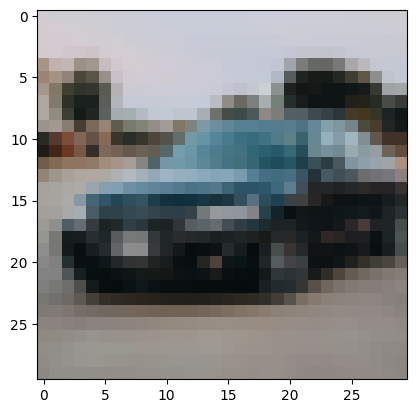

In [30]:
resized_image = Resize((30, 30))(image_car)
plt.imshow(resized_image) 

## Агументация датасета FasionMNIST

In [33]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, \
RandomHorizontalFlip, RandomVerticalFlip, Compose

In [34]:
transforms = Compose([RandomHorizontalFlip(p=0.3),
                      RandomVerticalFlip(p=0.3),
                      RandomRotation([-10, 10])])

dataset = FashionMNIST(root ='data/', download=True, transform=transforms)

100.0%
100.0%
100.0%
100.0%


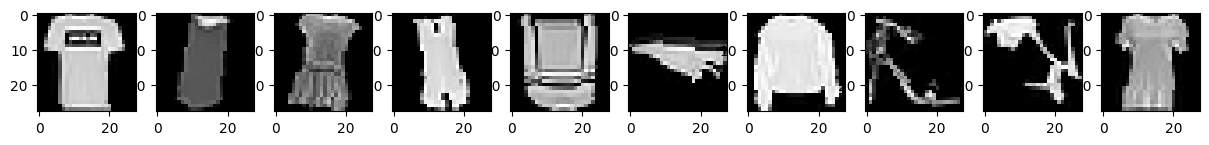

In [35]:
# Визуализация
fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = dataset[index]
    plt.subplot(1, 10, index)
    plt.imshow(image, cmap='gray')

# Transfer Learning

In [36]:
import torchvision
from torchsummary import summary
from torchvision.models import efficientnet_b0

In [40]:
# Модель для заморозки
model = efficientnet_b0(weights='IMAGENET1K_V1')
print("Параметры модели", model) 

Параметры модели EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): 

In [42]:
# Заморозка всех весов кроме линейного последнего
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

# Проверка
summary(model, input_size=(3, 224,224), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

### Переделаем на задачу классификации 10 классов

In [55]:
binary_classifier = nn.Sequential(
    nn.Linear(in_features=576, out_features=1024, bias=True),
    nn.Hardswish(),
    nn.Dropout(p=0.2),
    nn.Linear(in_features=1024, out_features=10, bias=True),
    nn.Sigmoid()
)
model.classifier = binary_classifier 
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## Пример установки модели с Kaggle

In [47]:
pip install timm kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 880.4 kB/s eta 0:00:00MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 1.9 MB/s eta 0:00:00 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 4.4 MB/s eta 0:00:009.6 MB/s eta 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [48]:
import timm
import kagglehub

In [49]:
# Download latest version
path = kagglehub.model_download("timm/tf-mobilenet-v3/pyTorch/tf-mobilenetv3-small-075")

print("Path to model files:", path)


  0%|                                                                                                                                              | 0.00/7.86M [00:00<?, ?B/s]
 13%|████████████████▉                                                                                                                    | 1.00M/7.86M [00:00<00:05, 1.35MB/s]
 25%|█████████████████████████████████▊                                                                                                   | 2.00M/7.86M [00:00<00:02, 2.63MB/s]
 38%|██████████████████████████████████████████████████▊                                                                                  | 3.00M/7.86M [00:01<00:01, 3.50MB/s]
 51%|███████████████████████████████████████████████████████████████████▋                                                                 | 4.00M/7.86M [00:01<00:01, 3.90MB/s]
 64%|████████████████████████████████████████████████████████████████████████████████████▌                             

Path to model files: /home/evgeniy/.cache/kagglehub/models/timm/tf-mobilenet-v3/pyTorch/tf-mobilenetv3-small-075/1


In [54]:
model_timm = timm.create_model('tf_mobilenetv3_small_075', 
                               checkpoint_path=(path+"/tf_mobilenetv3_small_075-da427f52.pth"))
print(model_timm)

MobileNetV3(
  (conv_stem): Conv2dSame(3, 16, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): Hardswish()
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2dSame(16, 16, kernel_size=(3, 3), stride=(2, 2), groups=16, bias=False)
        (bn1): BatchNormAct2d(
          16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): ReLU(inplace=True)
          (conv_expand): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (gate): Hardsigmoid()
        )
        (conv_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
         